# DEVELOPMENT OF THE FINITE DIFFERENCE METHOD ANALYSIS FOR VORTICITY FLOW SIMULATION
## Name : Aldiansyah Anugrah Ramadhan

## Library 

In [1]:
import os

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

## Folder Configuration

In [12]:
csv_dir = os.path.join('.', 'output', 'csv')
fig_dir = os.path.join('.', 'output', 'figure')
animation_dir = os.path.join('.', 'output', 'animation')

## Fluid Mechanics

### Reynolds Number

\begin{equation}
Re = \frac{UL}{\nu}
\end{equation}

### Vorticity Transport Equation

\begin{equation}
\frac{{\partial {\omega}}}{{\partial t}} + \frac{{\partial \psi }}{{\partial y}}\frac{{\partial {\omega}}}{{\partial x}} - \frac{{\partial \psi }}{{\partial x}}\frac{{\partial {\omega}}}{{\partial y}} = \nu (\frac{{\partial^{2} {\omega}}}{{\partial x^{2}}} + \frac{{\partial^{2} {\omega}}}{{\partial y^{2}}})
\end{equation}

### Poisson Equation

\begin{equation}
\frac{{\partial^{2} {\psi}}}{{\partial x^{2}}} + \frac{{\partial^{2} {\psi}}}{{\partial y^{2}}} = -\omega
\end{equation}

## Fourth-Order Runge-Kutta Method

\begin{equation}
	\frac{d\omega}{dt} =  f(t, \omega)
\end{equation}

\begin{equation}
	\omega^{n+1} = \omega^{n} + \frac{1}{6}(k_{1} + 2k_{2} + 2k_{3} + k_{4})
\end{equation}

\begin{align}
	k_{1} &= f(t, \omega)\Delta t \\
	k_{2} &= f\left(t + \frac{\Delta t}{2}, \omega + \frac{k_{1}}{2}\right)\Delta t \\
	k_{3} &= f\left(t + \frac{\Delta t}{2}, \omega + \frac{k_{2}}{2}\right)\Delta t \\
	k_{4} &= f(t + \Delta t, \omega + k_{3})\Delta t
\end{align}

## Finite Difference Method

### FTCS Scheme

\begin{equation}
	\frac{\partial u}{\partial x}\bigg|_{i,j}^n \approx \frac{u_{i+1,j}^n - u_{i-1,j}^n}{2\Delta x}
\end{equation}

\begin{equation}
	\frac{\partial u}{\partial y}\bigg|_{i,j}^n \approx \frac{u_{i,j+1}^n - u_{i,j-1}^n}{2\Delta y}
\end{equation}

\begin{equation}
	\frac{\partial^2 u}{\partial x^2}\bigg|_{i,j}^n \approx \frac{u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n}{\Delta x^2}
\end{equation}

\begin{equation}
	\frac{\partial^2 u}{\partial y^2}\bigg|_{i,j}^n \approx \frac{u_{i,j+1}^n - 2u_{i,j}^n + u_{i,j-1}^n}{\Delta y^2}
\end{equation}

\begin{equation}
	\frac{\partial u}{\partial t}\bigg|_{i,j}^n \approx \frac{u_{i,j}^{n+1} - u_{i,j}^n}{\Delta t}
\end{equation}

### Poisson Equation Discritization

\begin{equation}
\frac{{\psi_{i+1,j}^n - 2\psi_{i,j}^n + \psi_{i-1,j}^n}}{{\Delta {x^2}}} + \frac{{\psi_{i,j+1}^n - 2\psi_{i,j}^n + \psi_{i,j-1}^n}}{{\Delta {y^2}}} = -\omega_{i,j}^{n}
\end{equation}

\begin{equation}
\psi_{i,j}^{(k+1)} = \frac{\Delta{x^2}\Delta{y^2}}{2(\Delta{x^2}+\Delta{y^2})}\omega_{i,j}^{n} + \frac{\Delta y^{2}}{2(\Delta{x^2}+\Delta{y^2})}(\psi_{i+1,j}^{(k)} + \psi_{i-1,j}^{(k)}) + \frac{\Delta x^{2}}{2(\Delta{x^2}+\Delta{y^2})}({\psi_{i,j+1}^{(k)} + \psi_{i,j-1}^{(k)}})
\end{equation}

Point Succesive Over Relaxation (PSOR) Algorithm

\begin{equation}
\psi_{i,j}^{(k+1)} = \frac{\beta\Delta{x^2}\Delta{y^2}}{2(\Delta{x^2}+\Delta{y^2})}\omega_{i,j}^{n} + \frac{\beta\Delta y^{2}}{2(\Delta{x^2}+\Delta{y^2})}(\psi_{i+1,j}^{(k)} + \psi_{i-1,j}^{(k)}) + \frac{\beta\Delta x^{2}}{2(\Delta{x^2}+\Delta{y^2})}({\psi_{i,j+1}^{(k)} + \psi_{i,j-1}^{(k)}}) + (1-\beta)\psi_{i,j}^{(k)}
\end{equation}

### Vorticity Transport Equation Discritization

#### FTCS Scheme

\begin{equation}
C_{x} =  \left( {\frac{{\psi_{i,j+1}^n - \psi_{i,j-1}^n}}{{2\Delta y}}} \right)\left( {\frac{{\omega_{i+1,j}^n - \omega_{i-1,j}^n}}{{2\Delta x}}} \right)
\end{equation}

\begin{equation}
C_{y} = \left( {\frac{{\psi_{i+1,j}^n - \psi _{i-1,j}^n}}{{2\Delta x}}} \right)\left( {\frac{{\omega_{i,j+1}^n - \omega_{i,j-1}^n}}{{2\Delta y}}} \right)
\end{equation}

\begin{equation}
D_{xy} = \frac{{\omega_{i+1,j}^n - 2\omega_{i,j}^n + \omega _{i-1,j}^n}}{{\Delta {x^2}}} + \frac{{\omega_{i,j+1}^n - 2\omega_{i,j}^n + \omega_{i,j-1}^n}}{{\Delta {y^2}}}
\end{equation}

\begin{equation}
\omega_{i,j}^{n+1} = (\nu D_{xy} - C_{x} + C_{y})\Delta t + \omega_{i,j}^{n}
\end{equation}

#### RK4-CS Scheme

\begin{equation}
		\begin{split}
			\frac{d\omega_{i,j}}{dt} = {} & \nu \left( \frac{\omega_{i+1,j} - 2\omega_{i,j} + \omega_{i-1,j}}{\Delta x^2} + \frac{\omega_{i,j+1} - 2\omega_{i,j} + \omega_{i,j-1}}{\Delta y^2} \right) \\
			&- \left( \frac{\psi_{i,j+1} - \psi_{i,j-1}}{2\Delta y} \right) \left( \frac{\omega_{i+1,j} - \omega_{i-1,j}^n}{2\Delta x} \right) \\
			&+ \left( \frac{\psi_{i+1,j} - \psi_{i-1,j}}{2\Delta x} \right) \left( \frac{\omega_{i,j+1} - \omega_{i,j-1}^n}{2\Delta y} \right)
		\end{split}
\end{equation}

## Kondisi Awal

## Simulation

In [3]:
def initial_solution(nx, ny):
  psi_init = np.zeros([ny+1,nx+1])
  omega_init = np.zeros([ny+1,nx+1])
  return psi_init, omega_init

def spatial_step(nx, ny, lx, ly):
  dx = lx/nx
  dy = ly/ny
  return dx, dy

def reynolds_number(U, lx, nu):
  return U*lx/nu

def diffusion_number(nu, dx, dt):
  return nu*dt/dx**2

def courant_number(U, dx, dt):
  return U*dt/dx

def ftcs_is_stable(r, C):
  if (C**2 <= 4*r) & (r <= 1/4):
    return True
  else:
    return False

def rk4_is_stable(r, C):
  theta = np.pi/2
  Z = -8*r*np.sin(theta/2)**2 - 1j*C*np.sin(theta)
  G = 1 + Z + Z**2/2 + Z**3/6 + Z**4/24
  rho = np.abs(G)
  if (rho <= 1):
    return True
  else:
    return False

In [ ]:
# calculate stream function and vorticity using FTCS scheme
def ftcs_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U):
  psi = [psi_init]
  omega = [omega_init]
  ny, nx = psi_init.shape

  # poisson solver (PSOR)
  while t < tend:
    err = 1
    psi_iter = psi[-1].copy()
    omega_temp = omega[-1]
    while err > tol:
      psi_temp = np.zeros_like(psi_iter)
      psi_temp[1:-1,1:-1] = psi_iter[1:-1,1:-1]
      for i in range(1,nx-1):
        for j in range(1,ny-1):
          rhs = (dx*dy)**2*omega_temp[j,i]+dx**2*(psi_iter[j+1,i]+psi_iter[j-1,i])+dy**2*(psi_iter[j,i+1]+psi_iter[j,i-1])
          rhs *= beta/(2.0*(dx**2 + dy**2))
          psi_iter[j,i] = rhs + (1-beta)*psi_iter[j,i]
      err = np.linalg.norm(psi_iter - psi_temp)
    psi.append(psi_iter)

    omega_iter = np.zeros_like(omega_temp)

    # vorticity transport equation solver
    def compute_rhs(psi, omega, dx, dy, nu):
        Cx  = -(psi[2:,1:-1] - psi[:-2,1:-1])/(2.0*dy)*(omega[1:-1,2:]-omega[1:-1,:-2])/(2.0*dx)
        Cy  =  (omega[2:,1:-1] - omega[:-2,1:-1])/(2.0*dy)*(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
        Dxy =  (omega[1:-1,2:] - 2.0*omega[1:-1,1:-1]+omega[1:-1,:-2])/dx**2+(omega[2:,1:-1]-2.0*omega[1:-1,1:-1]+omega[:-2,1:-1])/dy**2
        rhs = Cx + Cy + nu*Dxy
        return rhs
  
    rhs = compute_rhs(psi_iter, omega_temp, dx, dy, nu)
    omega_iter[1:-1,1:-1] = omega_temp[1:-1,1:-1] + dt*rhs

    # apply boundary conditions
    omega_iter[0,1:-1]  = -2.0*psi_iter[1, 1:-1]/dy**2 # bottom wall
    omega_iter[-1,1:-1] = -2.0*psi_iter[-2, 1:-1]/dy**2 - 2.0*U/dy # top wall (moving at Uwall)
    omega_iter[1:-1,-1] = -2.0*psi_iter[1:-1,-2]/dx**2 # right wall
    omega_iter[1:-1,0]  = -2.0*psi_iter[1:-1,1]/dx**2 # left wall

    omega.append(omega_iter)
    t += dt
    print(t)

  return np.array(psi), np.array(omega)

In [4]:
# calculate stream function and vorticity using RK4-CS scheme
def rk4_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U):
  psi = [psi_init]
  omega = [omega_init]
  ny, nx = psi_init.shape

  # poisson solver (PSOR)
  while t < tend:
    err = 1
    psi_iter = psi[-1].copy()
    omega_temp = omega[-1]
    while err > tol:
      psi_temp = np.zeros_like(psi_iter)
      psi_temp[1:-1,1:-1] = psi_iter[1:-1,1:-1]
      for i in range(1,nx-1):
        for j in range(1,ny-1):
          rhs = (dx*dy)**2*omega_temp[j,i]+dx**2*(psi_iter[j+1,i]+psi_iter[j-1,i])+dy**2*(psi_iter[j,i+1]+psi_iter[j,i-1])
          rhs *= beta/(2.0*(dx**2 + dy**2))
          psi_iter[j,i] = rhs + (1-beta)*psi_iter[j,i]
      err = np.linalg.norm(psi_iter - psi_temp)
    psi.append(psi_iter)

    omega_iter = np.zeros_like(omega_temp)

    # vorticity transport equation solver
    def compute_rhs(psi, omega, dx, dy, nu):
        Cx  = -(psi[2:,1:-1] - psi[:-2,1:-1])/(2.0*dy)*(omega[1:-1,2:]-omega[1:-1,:-2])/(2.0*dx)
        Cy  =  (omega[2:,1:-1] - omega[:-2,1:-1])/(2.0*dy)*(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
        Dxy =  (omega[1:-1,2:] - 2.0*omega[1:-1,1:-1]+omega[1:-1,:-2])/dx**2+(omega[2:,1:-1]-2.0*omega[1:-1,1:-1]+omega[:-2,1:-1])/dy**2
        rhs = Cx + Cy + nu*Dxy
        return rhs

    # RK4 solver
    k1 = compute_rhs(psi_iter, omega_temp, dx, dy, nu)

    k_temp = omega_temp.copy()
    k_temp[1:-1,1:-1] += 0.5*dt*k1
    k2 = compute_rhs(psi_iter, k_temp, dx, dy, nu)
    
    k_temp[1:-1,1:-1] = omega_temp[1:-1,1:-1] + 0.5*dt*k2 
    k3 = compute_rhs(psi_iter, k_temp, dx, dy, nu)

    k_temp[1:-1,1:-1] = omega_temp[1:-1,1:-1] + dt*k3
    k4 = compute_rhs(psi_iter, k_temp, dx, dy, nu)

    omega_iter[1:-1, 1:-1] = omega_temp[1:-1, 1:-1] + (dt / 6.0)*(k1+2*k2+2*k3+k4)

    # apply boundary conditions
    omega_iter[0,1:-1]  = -2.0*psi_iter[1, 1:-1]/dy**2 # bottom wall
    omega_iter[-1,1:-1] = -2.0*psi_iter[-2, 1:-1]/dy**2 - 2.0*U/dy # top wall (moving at Uwall)
    omega_iter[1:-1,-1] = -2.0*psi_iter[1:-1,-2]/dx**2 # right wall
    omega_iter[1:-1,0]  = -2.0*psi_iter[1:-1,1]/dx**2 # left wall

    omega.append(omega_iter)
    t += dt
    print(t)

  return np.array(psi), np.array(omega)

In [5]:
# convert stream function into velocity
def velocity_component(psi, dx, dy, U):
  # initial condition
  u = np.zeros_like(psi)
  v = np.zeros_like(psi)

  # boundary conditions
  u[:,-1,:] = U

  # calculate u and v
  u[:,1:-1,1:-1] = (psi[:,2:,1:-1]-psi[:,:-2,1:-1])/(2.0*dy)
  v[:,1:-1,1:-1] = -(psi[:,1:-1,2:]-psi[:,1:-1,:-2])/(2.0*dx)
  
  return u, v

In [6]:
# create the animation of vorticity flow
def animate_cavity_flow(lx, ly, t, tend, u, v, title, save_filename):
    nt, ny, nx = u.shape
    x = np.linspace(0, lx, nx)
    y = np.linspace(0, ly, ny)
    t = np.linspace(t, tend, nt)
    X, Y = np.meshgrid(x, y)
    velocity = np.sqrt(u**2 + v**2)

    fig, ax = plt.subplots(figsize=(8, 6))
    v_min, v_max = velocity.min(), velocity.max()

    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=v_min, vmax=v_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Velocity Magnitude')

    def update(frame):
        ax.clear()
        cont = ax.contourf(X, Y, velocity[frame], levels=20, alpha=0.5,
                           cmap='viridis', vmin=v_min, vmax=v_max)
        ax.streamplot(X, Y, u[frame], v[frame], color='k', density=1, linewidth=1)

        ax.set_title(f'{title}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(0, lx)
        ax.set_ylim(0, ly)
        ax.set_aspect('equal')

        curr_time = t[frame]
        ax.text(0.02, 0.93, f"t = {curr_time:.4f} s",
                transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5))
        return ax.artists

    step_size = max(1, nt // 50)
    frames_to_show = range(0, nt, step_size)

    ani = FuncAnimation(fig, update, frames=frames_to_show, interval=100, blit=False)

    if save_filename:
        print(f"Saving animation to {save_filename}...")
        if save_filename.endswith('.mp4'):
            ani.save(save_filename, writer='ffmpeg', fps=10)
        elif save_filename.endswith('.gif'):
            ani.save(save_filename, writer='pillow', fps=10)
        print("Save complete.")

    plt.close()
    # return HTML(ani.to_jshtml())
    return ani

### Numerical and physical parameter

In [7]:
# physical parameter
U = 1 # top wall velocity
nu = 2e-4 # kinematic viscocity
t = 22.5 # initial time
tend = t + 7.5 # end time

# numerical parameter
nx = ny = 125 # grid number
lx = ly = 1 # wall length
tol = 1e-4 # error tolerance
beta = 1.75 # PSOR parameter
dx, dy = spatial_step(nx, ny, lx, ly) # spatial step
dt = 7.5*10**(-4) # time step
re = reynolds_number(U, lx, nu) # reynolds number
diffusion = diffusion_number(nu, dx, dt) # diffusion number
courant = courant_number(U, dx, dt) # courant number
ftcs_condition = ftcs_is_stable(diffusion, courant) # FTCS stability condition
rk4_condition = rk4_is_stable(diffusion, courant) # RK4-CS stability condition

print('Re:', re)
print('r:', diffusion)
print('C:', courant)
print('Is FTCS stable:', ftcs_condition)
print('Is RK4 stable:', rk4_condition)

Re: 5000.0
r: 0.0023437500000000003
C: 0.09375
Is FTCS stable: True
Is RK4 stable: True


### FTCS Scheme

In [ ]:
# initiate the solution
psi_init, omega_init = initial_solution(nx, ny)

# read the results of stream function and vorticity from CSV file
# psi_init = np.loadtxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), delimiter=',')
# omega_init = np.loadtxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), delimiter=',')

# calculate the solution in stream function and vorticity
psi_ftcs, omega_ftcs = ftcs_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U)

# convert stream function into velocity
u_ftcs, v_ftcs = velocity_component(psi_ftcs, dx, dy, U)

In [ ]:
# create the animation of vorticity flow
animate_cavity_flow(lx, ly, t, tend, u_ftcs, v_ftcs, 'Aliran Fluida pada Kondisi Turbulen - Skema FTCS', os.path.join(animation_dir, 'ftcsre5000part4.mp4'))

In [ ]:
# save the result (t = tend) to CSV file
psi_init_ftcs = psi_ftcs[-1]
omega_init_ftcs = omega_ftcs[-1]
np.savetxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), psi_init_ftcs, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), omega_init_ftcs, delimiter=',')

### RK4-CS Scheme

In [8]:
# initiate the solution
# psi_init, omega_init = initial_solution(nx, ny)

# read the results of stream function and vorticity from CSV file
psi_init = np.loadtxt(os.path.join(csv_dir, 'psi_init_rk4_turbulen.csv'), delimiter=',')
omega_init = np.loadtxt(os.path.join(csv_dir, 'omega_init_rk4_turbulen.csv'), delimiter=',')

# calculate the solution in stream function and vorticity
psi_rk4, omega_rk4 = rk4_solver(psi_init, omega_init, dx, dy, dt, t, tend, tol, beta, nu, U)

# convert stream function into velocity
u_rk4, v_rk4 = velocity_component(psi_rk4, dx, dy, U)

22.50075
22.5015
22.50225
22.503
22.50375
22.5045
22.50525
22.506
22.50675
22.5075
22.50825
22.509
22.50975
22.5105
22.51125
22.512
22.51275
22.5135
22.51425
22.515
22.51575
22.5165
22.51725
22.518
22.51875
22.5195
22.52025
22.521
22.52175
22.5225
22.52325
22.524
22.52475
22.5255
22.52625
22.527
22.52775
22.5285
22.52925
22.53
22.53075
22.5315
22.53225
22.533
22.53375
22.5345
22.53525
22.536
22.53675
22.5375
22.53825
22.539
22.53975
22.5405
22.54125
22.542
22.54275
22.5435
22.54425
22.545
22.54575
22.5465
22.547250000000002
22.548000000000002
22.548750000000002
22.549500000000002
22.550250000000002
22.551000000000002
22.551750000000002
22.552500000000002
22.553250000000002
22.554000000000002
22.554750000000002
22.555500000000002
22.556250000000002
22.557000000000002
22.557750000000002
22.558500000000002
22.559250000000002
22.560000000000002
22.560750000000002
22.561500000000002
22.562250000000002
22.563000000000002
22.563750000000002
22.564500000000002
22.565250000000002
22.56600000000

In [10]:
# create the vorticity flow in MP4 
animate_cavity_flow(lx, ly, t, tend, u_rk4, v_rk4, 'Aliran Fluida pada Kondisi Laminar - Skema RK4-CS', os.path.join(animation_dir, 'rk4re5000part4.mp4'))

Saving animation to .\output\animation\rk4re5000part4.mp4...
Save complete.


In [11]:
# save the result (t = tend) to CSV file
psi_init_rk4 = psi_rk4[-1]
omega_init_rk4 = omega_rk4[-1]
np.savetxt(os.path.join(csv_dir, 'psi_init_rk4_turbulen.csv'), psi_init_rk4, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'omega_init_rk4_turbulen.csv'), omega_init_rk4, delimiter=',')

## Comparison of the Results

In [12]:
# convert stream function into velocity (in 2D)
def velocity_component_2d(psi, dx, dy, U):
  # initial condition
  u = np.zeros_like(psi)
  v = np.zeros_like(psi)

  # boundary conditions
  u[-1,:] = U

  u[1:-1,1:-1] = (psi[2:,1:-1]-psi[:-2,1:-1])/(2.0*dy)
  v[1:-1,1:-1] = -(psi[1:-1,2:]-psi[1:-1,:-2])/(2.0*dx)
  
  return u, v

In [ ]:
# load the results of stream function and vorticity from CSV file
omega_init_ftcs = np.loadtxt(os.path.join(csv_dir, 'omega_init_ftcs_turbulen.csv'), delimiter=',')
psi_init_ftcs = np.loadtxt(os.path.join(csv_dir, 'psi_init_ftcs_turbulen.csv'), delimiter=',')

omega_init_rk4 = np.loadtxt(os.path.join(csv_dir, 'omega_init_rk4_turbulen.csv'), delimiter=',')
psi_init_rk4 = np.loadtxt(os.path.join(csv_dir, 'psi_init_rk4_turbulen.csv'), delimiter=',')

In [ ]:
# convert stream function into velocity
u_ftcs, v_ftcs = velocity_component_2d(psi_init_ftcs, dx, dy, U)
np.savetxt(os.path.join(csv_dir, 'u_ftcs_turbulen.csv'), u_ftcs, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'v_ftcs_turbulen.csv'), v_ftcs, delimiter=',')

u_rk4, v_rk4 = velocity_component_2d(psi_init_rk4, dx, dy, U)
np.savetxt(os.path.join(csv_dir, 'u_rk4_turbulen.csv'), u_rk4, delimiter=',')
np.savetxt(os.path.join(csv_dir, 'v_rk4_turbulen.csv'), v_rk4, delimiter=',')

In [4]:
# load the results of velocity component from CSV file
# u_ftcs_laminar = np.loadtxt(os.path.join(csv_dir, 'u_ftcs_laminar.csv'), delimiter=',')
# v_ftcs_laminar = np.loadtxt(os.path.join(csv_dir, 'v_ftcs_laminar.csv'), delimiter=',')

u_rk4_laminar = np.loadtxt(os.path.join(csv_dir, 'u_rk4_laminar.csv'), delimiter=',')
v_rk4_laminar = np.loadtxt(os.path.join(csv_dir, 'v_rk4_laminar.csv'), delimiter=',')

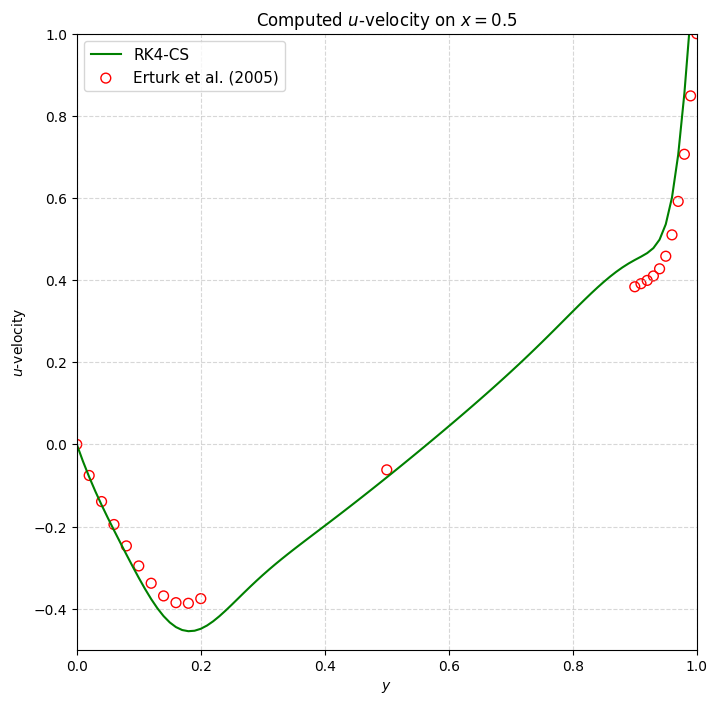

In [16]:
# plot of the u-velocity
nx, ny = u_rk4_laminar.shape
y_simulation = np.linspace(0, 1, ny)
x_mid_index = nx//2
# u_selected_ftcs = u_ftcs_laminar[:, x_mid_index]
u_selected_rk4 = u_rk4_laminar[:, x_mid_index]

y_erturk = np.array([0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.50, 0.90,
                   0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00])

u_erturk_laminar = np.array([0.00, -0.0757, -0.1392, -0.1951, -0.2472, -0.2960, -0.3381, -0.3690, -0.3854, -0.3869, -0.3756, -0.0620, 0.3838, 0.3913,
                   0.3993, 0.4101, 0.4276, 0.4582, 0.5102, 0.5917, 0.7065, 0.8486, 1.00])

u_erturk_turbulent = np.array([0.00, -0.2223, -0.3480, -0.4272, -0.4419, -0.4168, -0.3876, -0.3652, -0.3467, -0.3285, -0.3100, -0.0319, 0.4155,
                    0.4307, 0.4452, 0.4582, 0.4683, 0.4738, 0.4739, 0.4749, 0.5159, 0.6866, 1.00])

plt.figure(figsize=(8, 8))

# plt.plot(y_simulation, u_selected_ftcs, label='FTCS', color='blue')
# plt.plot(y_simulation, u_selected_rk4, label='RK4-CS', color='green', linestyle='dashed')
plt.plot(y_simulation, u_selected_rk4, label='RK4-CS', color='green')
plt.scatter(y_erturk, u_erturk_laminar, color='red', marker='o', facecolors='none', edgecolors='red', 
            s=50, label='Erturk et al. (2005)')

plt.title('Computed $u$-velocity on $x=0.5$')
plt.xlabel('$y$')
plt.ylabel('$u$-velocity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11)
plt.xlim([0.0, 1.0])
plt.ylim([-0.5, 1.0])
plt.savefig(os.path.join(fig_dir, 'u_velocity.png'))
plt.show()

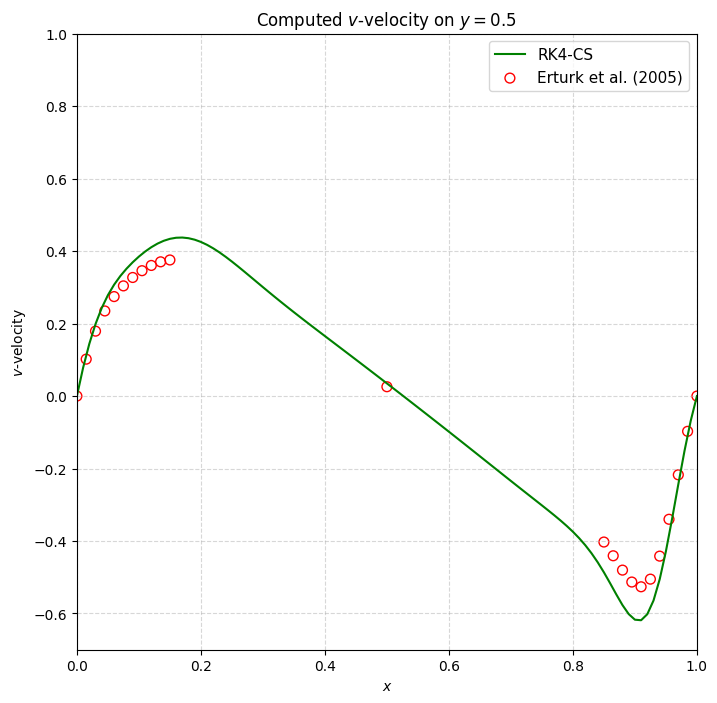

In [20]:
# plot of the v-velocity
nx, ny = v_rk4_laminar.shape
x_simulation = np.linspace(0, 1, nx)
y_mid_index = ny//2
# v_selected_ftcs = v_ftcs[y_mid_index, :]
v_selected_rk4 = v_rk4_laminar[y_mid_index, :]

x_erturk = np.array([0.00, 0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.12, 0.135, 0.15, 0.50, 0.85,
                   0.865, 0.88, 0.895, 0.91, 0.925, 0.94, 0.955, 0.97, 0.985, 1.00])

v_erturk_laminar = np.array([0.00, 0.1019, 0.1792, 0.2349, 0.2746, 0.3041, 0.3273, 0.3460, 0.3605, 0.3705, 0.3756, 0.0258, -0.4028, -0.4407,
                   -0.4803, -0.5132, -0.5263, -0.5052, -0.4417, -0.3400, -0.2173, -0.0973, 0.00])

v_erturk_turbulent = np.array([0.00,-0.2441,-0.5019,-0.5700,-0.5139, -0.4595, -0.4318, -0.4147, -0.3982, -0.3806, -0.3624, 0.0117, 0.3699,
                    0.3878, 0.4070, 0.4260, 0.4403, 0.4426, 0.4258, 0.3868, 0.3263, 0.2160, 0.00])

plt.figure(figsize=(8, 8))

# plt.plot(x_simulation, v_selected_ftcs, label='FTCS', color='blue')
# plt.plot(x_simulation, v_selected_rk4, label='RK4-CS', color='green', linestyle='dashed')
plt.plot(x_simulation, v_selected_rk4, label='RK4-CS', color='green')
plt.scatter(x_erturk, v_erturk_laminar, color='red', marker='o', facecolors='none', edgecolors='red', 
            s=50, label='Erturk et al. (2005)')

plt.title('Computed $v$-velocity on $y=0.5$')
plt.xlabel('$x$')
plt.ylabel('$v$-velocity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11)
plt.xlim([0.0, 1.0])
plt.ylim([-0.7, 1.0])
plt.savefig(os.path.join(fig_dir, 'v_velocity.png'))
plt.show()